In [1]:
import numpy as np
import matplotlib.pyplot as plt
import construct as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetLanguage
from IndividualParcellation.global_config import *
import OptimalBattery.estimate as es
import OptimalBattery.util as ut
import OptimalBattery.construct as ct

Default device set to: cuda


# define atlas and dirs

In [2]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')

In [49]:
# roi (full cerebellum)
ROI_cortex = [28,29,39,31,32]
atlas_dir = f'{func_fus_dir}/Atlases/tpl-SUIT'
model_name = f'{atlas_dir}/atl-NettekovenSym32_space-SUIT_dseg.nii'
parcelation = atlas.read_data(model_name)
ROI_mask = np.isin(parcelation, ROI_cortex)
ROI_indices = np.where(ROI_mask)[0]
print(len(ROI_indices))


922


# Load data

- mdtb_1 - run: Data used to make libray of tasks and to use task batteries for parcellations
- mdtb_1 - all: Data used to pick the Vs of the top parcels
- mdtb_2 - all: Data used to test parcellation predicition error

In [50]:
MDTB_dataset = DataSetLanguage(f'{func_fus_dir}/Language')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-localizer_cond',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]
info_mdtb_1_run['taskName'] = [x.split(' ')[0] for x in info_mdtb_1_run['taskName']]




data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-localizer_cond',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]
info_mdtb_1_all['taskName'] = [x.split(' ')[0] for x in info_mdtb_1_all['taskName']]


data_mdtb_s1_half,info_mdtb_1_half  =MDTB_dataset.get_data(space=space,ses_id='ses-localizer_cond',type='CondHalf')
data_mdtb_s1_half[np.isnan(data_mdtb_s1_half)] = 0
data_mdtb_s1_half = data_mdtb_s1_half[:,:,:]
info_mdtb_1_half['taskName'] = [x.split(' ')[0] for x in info_mdtb_1_half['taskName']]

In [51]:
data_mdtb_s1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='taskName',center_condition='rest')
data_mdtb_s1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='taskName',center_condition='rest')
data_mdtb_s1_half = ut.recenter_fmri_data(data_mdtb_s1_half,info_mdtb_1_half,task_column_name='taskName',center_condition='rest')

In [52]:
data_mdtb_s1_half_1 = data_mdtb_s1_half[:,:int(data_mdtb_s1_half.shape[1]/2),:]
data_mdtb_s1_half_2 = data_mdtb_s1_half[:,int(data_mdtb_s1_half.shape[1]/2):,:]

# Get crossvalidated second moment matrix (GLib)

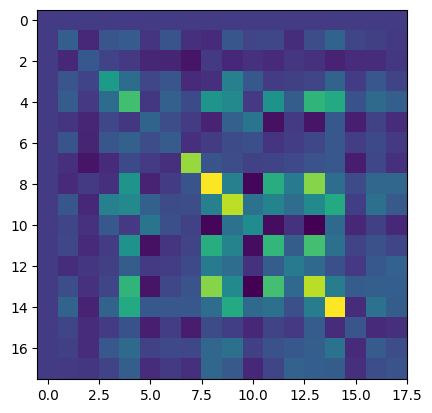

In [53]:
cond_vec = np.tile(np.arange(1, 18 + 1), 8)
part_vec = np.repeat(np.arange(1, 8 + 1), 18)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib)

In [54]:
# get eigenvalues
eig_Lib = np.linalg.eig(G_Lib)[0]
#sort
eig_Lib = np.sort(eig_Lib)[::-1]
print(eig_Lib)

# avg the diagonal of E
E_mean = np.mean(E_list, axis=0)
# get the diagonal of E
diag = np.diag(E_mean)
#avg the diagonal
diag_mean = np.mean(diag)
print(diag_mean)


[ 0.07910537  0.03751202  0.0212906   0.01401248  0.01077869  0.0087172
  0.00720615  0.00542445  0.00331035  0.00298253  0.00111595  0.00104623
  0.00033776  0.         -0.00010822 -0.0002393  -0.00073869 -0.00450905]
0.08862660703856474


In [55]:
# find indices in info_run that has half  = 1
half_idx = np.where(info_mdtb_1_run['half'] == 1)[0]
train_run = data_mdtb_s1_run[:,half_idx,:]
info_mdtb_1_run = info_mdtb_1_run.iloc[half_idx]
info_mdtb_1_run = info_mdtb_1_run.reset_index(drop=True)
info_mdtb_1_run[:19]

,run,reg_id,n_rep,Unnamed: 0,taskName,task,inst,instOrder,time,sess,half,names
0,2,1,1.0,20,rest,1,0,0,6.100014,1,1,rest-run2
1,2,2,1.0,21,word_reading,2,0,0,21.100010,1,1,word_reading-run2
2,2,3,1.0,22,verb_GENERATION,3,0,0,356.100000,1,1,verb_GENERATION-run2
3,2,4,1.0,23,action_observation_action,4,0,0,371.100000,1,1,action_observation_action-run2
4,2,5,1.0,24,action_observation,5,0,0,531.100000,1,1,action_observation-run2
5,2,6,1.0,25,intact_passage,6,0,0,181.100000,1,1,intact_passage-run2
6,2,7,1.0,26,degraded_passage,7,0,0,286.229200,1,1,degraded_passage-run2
7,2,8,1.0,27,tongue_movement,8,0,0,76.111220,1,1,tongue_movement-run2
8,2,9,1.0,28,finger_sequence,9,0,0,321.100000,1,1,finger_sequence-run2
9,2,10,1.0,29,theory_of_mind,10,0,0,146.100000,1,1,theory_of_mind-run2


# Build dataframes with different task battery size (n_tasks) and different number of parcels (n_parcels) and evaluate

In [58]:
# make data pt tensor
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
train_all  = pt.tensor(data_mdtb_s1_all, dtype=pt.float32, device=device)
test_all = pt.tensor(data_mdtb_s1_half_2, dtype=pt.float32, device=device)
train_run = pt.tensor(train_run, dtype=pt.float32, device=device)
parcelation = pt.tensor(parcelation, dtype=pt.float32, device=device)
ROI_mask = pt.tensor(ROI_mask, dtype=pt.float32, device=device)


c:\Users\barafat\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


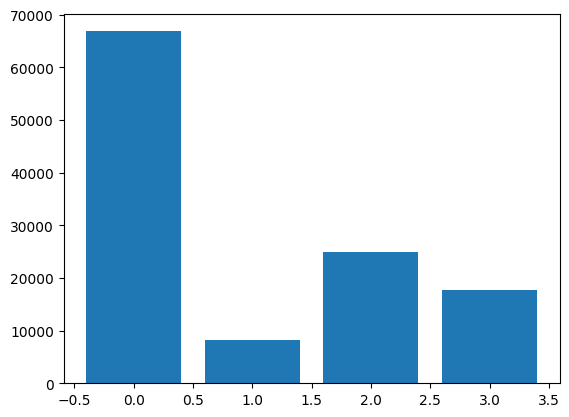

In [60]:
full_vs_train = es.estimate_Vs(train_all,parcellation=parcelation,ROI_mask= ROI_mask)
full_vs_test = es.estimate_Vs(test_all,parcellation=parcelation,ROI_mask=ROI_mask)

# Get list of parcels ordered by size by counting voxel assignments across subjects
Us = es.estimate_Us(train_all, full_vs_train,method='correlation',hard=True)
parcel_counts = Us.sum(dim=(0,2))
sorted_parcels = pt.argsort(parcel_counts, descending=True).cpu().numpy()
parcel_counts = parcel_counts.cpu().numpy()
total_parcels = len(sorted_parcels)

plt.bar(range(len(parcel_counts)), parcel_counts)
plt.show()

In [61]:
def get_condition_indices(df):
    """
    Get condition indices from a dataframe and record the duration of each condition
    Parameters:
        df(pd.DataFrame): dataframe containing condition indices needs to include:
            - 'cond_name': name of the condition
            - 'run': run number
            - 'task_name': name of the task
    Returns:
        condition_indices(np.ndarray): condition indices
    """
    unique_conditions = df['taskName'].unique()
    new_df = pd.DataFrame(columns=['taskName', 'indices', 'duration'])
    
    # Filter only the first run
    first_run_df = df[df['run'] == df['run'].min()]
    task_run_counts = first_run_df.groupby('taskName')['taskName'].nunique()
    duration_map = {1: 30, 2: 15, 3: 10}
    
    # Populate the new dataframe
    for condition in unique_conditions:
        indices = df[df['taskName'] == condition].index.tolist()
        
        # Identify task_name for the condition from the original dataframe
        task_name = df[df['taskName'] == condition]['taskName'].values[0]
        num_conditions = task_run_counts.get(task_name, 1)
        duration = duration_map.get(num_conditions, 30)
        
        new_row = {'taskName': condition, 'indices': indices, 'duration': duration}
        new_df = pd.concat([new_df, pd.DataFrame([new_row])], ignore_index=True)
    
    return new_df
condition_df= get_condition_indices(info_mdtb_1_run)

In [62]:
battery_sizes = [4,5,6,7,8,10]
# parcel_sizes = [2,4,6,8,10,16,total_parcels]

parcel_sizes = [3,4]
# battery_sizes = [4,6]


In [64]:
results_df = pd.DataFrame()
for n_parcel in parcel_sizes:
    print(f"Processing parcel size: {n_parcel}")
    parcel_indices = sorted_parcels[:n_parcel]
    VLib = full_vs_train[:,parcel_indices]
    Vtest = full_vs_test[:,parcel_indices]
    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")
        # Generate possible battery combinations for current battery size and calculate eigenmetrics
        D = ct.build_combinations(G_Lib, strategy='random',n_batteries=1000,n_tasks=n_task,seed=1,replacement=False,rest_idx=0)
        D_ev = ev.evluate_dataframe( D = D, condition_df= condition_df, YLib= train_run,
                                     VLib= VLib, Ytest= test_all, Vtest= Vtest,indices=None)

        D_ev['n_parcel'] = n_parcel
        D_ev['n_task'] = n_task

        results_df = pd.concat([results_df, D_ev], ignore_index=True)
    



Processing parcel size: 3
Processing battery size: 4
Processing combination: 0
Processing battery size: 5
Processing combination: 0
Processing battery size: 6
Processing combination: 0
Processing battery size: 7
Processing combination: 0
Processing battery size: 8
Processing combination: 0
Processing battery size: 10
Processing combination: 0
Processing parcel size: 4
Processing battery size: 4
Processing combination: 0
Processing battery size: 5
Processing combination: 0
Processing battery size: 6
Processing combination: 0
Processing battery size: 7
Processing combination: 0
Processing battery size: 8
Processing combination: 0
Processing battery size: 10
Processing combination: 0


In [60]:
name = os.path.join(base_dir, 'OptimalBattery','Eval_tsvs', 'cerebellum_MDTB_ses-01_ses-02_results_5000itr_replace.tsv')

# save to tsv
# results_df.to_csv(name, sep="\t", index=False)

#load
# results_df = pd.read_csv(name, sep="\t")

# Make proposal sets (sampling with repelcament from the batteries evaluated) for each n_tasks and n_parcels

In [65]:
n_proposal_sets = 100
metrics = ["variance", "variance_mc", "log_det_mc"] # Metrics to evaluate


# Get unique values of n_parcel and n_task from the results dataframe
unique_n_parcel = results_df["n_parcel"].unique()
unique_n_task = results_df["n_task"].unique()



In [66]:
proposals_list = []
for n_parcel in unique_n_parcel:
    print(f"Processing parcel size: {n_parcel}")
    for n_task in unique_n_task:
        print(f"Processing battery size: {n_task}")
        subset_df = results_df[(results_df["n_parcel"] == n_parcel) & (results_df["n_task"] == n_task)]
        
        for iter in range(n_proposal_sets):
            sampled_df = subset_df.sample(len(subset_df), replace=True)
            
            for metric in metrics:
                best_row = sampled_df.loc[sampled_df[metric].idxmax()]
                # if the same top battery is proposed multiple times, only keep the first instance
                if isinstance(best_row, pd.DataFrame):
                    best_row = best_row.iloc[0]
                
                cos_subjects = best_row["cos_subjects"]
                proposals_list.append({
                    "n_iter": iter,
                    "n_parcel": n_parcel,
                    "n_task": n_task,
                    "metric": metric,
                    "cos_subjects": cos_subjects,
                })


iter_df = pd.DataFrame(proposals_list)

Processing parcel size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 10
Processing parcel size: 4
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 10


# seperate the list of prediction errors of all subjects into values for each subject for the top battery by each metric in each iteration for each n_tasks and n_parcels

after seperating

In [67]:
expanded_results = []
for _, row in iter_df.iterrows():
    # if its a string with [] then convert to list
    if isinstance(row["cos_subjects"], str):
        row["cos_subjects"] = eval(row["cos_subjects"])
    row_cos_values = row["cos_subjects"]
    for i,subj_cos in enumerate(row_cos_values):
        cos_value = row_cos_values[i]
        expanded_results.append({
            "n_iter": row["n_iter"],
            "n_parcel": row["n_parcel"],
            "n_task": row["n_task"],
            "metric": row["metric"],
            "subject": i+1,
            "cos_value": cos_value
        })
# this is just expanded version of the iter_df
expanded_results_df = pd.DataFrame(expanded_results)

# this averages the results for each subject across all iterations
averaged_results_df = (
    expanded_results_df
    .groupby(["n_parcel", "n_task", "metric", "subject"], as_index=False)
    .agg({"cos_value": "mean"})
)

# Aggregate across subjects to get mean and SEM
aggregated_results_df = averaged_results_df.groupby(["n_parcel", "n_task", "metric"], as_index=False).agg(
    cos_mean=("cos_value", "mean"),
    cos_sem=("cos_value", lambda x: x.std() / np.sqrt(len(x)))  # SEM
)

# make a df for the baseline battery

In [68]:
baseline_df = results_df.copy()
if isinstance(baseline_df["cos_subjects"].iloc[0], str):
    baseline_df["cos_subjects"] = baseline_df["cos_subjects"].apply(eval)
baseline_df = baseline_df.explode("cos_subjects")  
baseline_df["cos_subjects"] = baseline_df["cos_subjects"].astype(float)

baseline_aggregated_df = baseline_df.groupby(["n_parcel", "n_task"], as_index=False).agg(
    cos_mean=("cos_subjects", "mean")
)

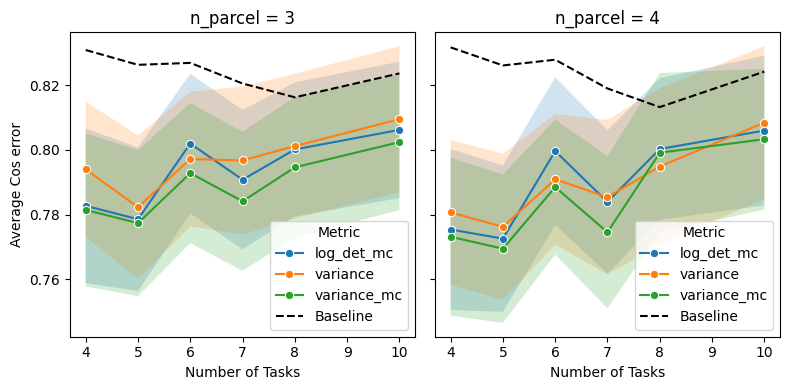

In [69]:
num_plots = len(unique_n_parcel)
n_cols = int(np.ceil(np.sqrt(num_plots))) 
n_rows = int(np.ceil(num_plots / n_cols)) 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharex=False, sharey=True)
axes = np.array(axes).flatten()

for ax, n_parcel in zip(axes, unique_n_parcel):
    df_plot = aggregated_results_df[aggregated_results_df["n_parcel"] == n_parcel]
    sns.lineplot(
        data=df_plot, x="n_task", y="cos_mean", hue="metric", ax=ax, marker="o"
    )

    for metric in df_plot["metric"].unique():
        metric_data = df_plot[df_plot["metric"] == metric]
        ax.fill_between(metric_data["n_task"],
                        metric_data["cos_mean"] - metric_data["cos_sem"],
                        metric_data["cos_mean"] + metric_data["cos_sem"],
                        alpha=0.2)

    # Plot the baseline for this n_parcel
    baseline_data = baseline_aggregated_df[baseline_aggregated_df["n_parcel"] == n_parcel]
    sns.lineplot(
        data=baseline_data, x="n_task", y="cos_mean", ax=ax, color="black", linestyle="dashed", label="Baseline"
    )
    ax.set_title(f"n_parcel = {n_parcel}")
    ax.set_xlabel("Number of Tasks")
    ax.set_ylabel("Average Cos error")
    ax.legend(title="Metric")

# Hide unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

